In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!nvidia-smi

Fri Jul  3 04:53:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch

print("="*50)
print("GPU Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")
print("="*50)

Mounted at /content/drive
GPU Available : True
GPU Name : Tesla T4


In [ ]:
!pip -q install transformers timm accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
dataset_path = "/content/drive/MyDrive/research_data/final_dataset"

print("Folders:")
print(os.listdir(dataset_path))

print()

print("Real Images :", len(os.listdir(os.path.join(dataset_path,"real"))))
print("Fake Images :", len(os.listdir(os.path.join(dataset_path,"fake"))))

Folders:
['real', 'fake']

Real Images : 5000
Fake Images : 7100


In [ ]:
from torchvision import datasets
from torch.utils.data import random_split

dataset = datasets.ImageFolder("/content/drive/MyDrive/research_data/final_dataset")

print("Classes :", dataset.classes)
print("Total Images :", len(dataset))

train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("="*40)
print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Classes : ['fake', 'real']
Total Images : 12100
Train : 8470
Validation : 1815
Test : 1815


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_path = "/content/drive/MyDrive/research_data/final_dataset"

data = []

for label in ["real", "fake"]:
    folder = os.path.join(dataset_path, label)

    for img in os.listdir(folder):
        data.append({
            "image_path": os.path.join(folder, img),
            "label": label
        })

df = pd.DataFrame(data)

print(df.head())
print("\nTotal Images:", len(df))

                                          image_path label
0  /content/drive/MyDrive/research_data/final_dat...  real
1  /content/drive/MyDrive/research_data/final_dat...  real
2  /content/drive/MyDrive/research_data/final_dat...  real
3  /content/drive/MyDrive/research_data/final_dat...  real
4  /content/drive/MyDrive/research_data/final_dat...  real

Total Images: 12100


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Train : 8470
Validation : 1815
Test : 1815


In [ ]:
save_path = "/content/drive/MyDrive/research_data"

train_df.to_csv(os.path.join(save_path, "train.csv"), index=False)
val_df.to_csv(os.path.join(save_path, "val.csv"), index=False)
test_df.to_csv(os.path.join(save_path, "test.csv"), index=False)

print("CSV files saved successfully!")

CSV files saved successfully!


In [ ]:
from PIL import Image
from torch.utils.data import Dataset

label_map = {
    "real": 0,
    "fake": 1
}

class DeepfakeDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "image_path"]
        label = label_map[self.df.loc[idx, "label"]]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = DeepfakeDataset(train_df, train_transform)
val_dataset   = DeepfakeDataset(val_df, test_transform)
test_dataset  = DeepfakeDataset(test_df, test_transform)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

8470
1815
1815


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 265
Validation batches : 57
Test batches : 57


**First Model Training->EfficientNet-B0 Training**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from transformers import AutoImageProcessor
from transformers import AutoModelForImageClassification

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

Device : cuda


In [ ]:
model_name = "google/efficientnet-b0"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

model.to(device)

print("Model Loaded Successfully!")

preprocessor_config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[transformers] EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b0
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1280]) vs model:torch.Size([2, 1280])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model Loaded Successfully!


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    )
])

In [ ]:
train_dataset = DeepfakeDataset(train_df, train_transform)
val_dataset = DeepfakeDataset(val_df, test_transform)
test_dataset = DeepfakeDataset(test_df, test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Ready for Training!")

Ready for Training!


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

EPOCHS = 5

print("Loss Function :", criterion)
print("Optimizer :", optimizer)
print("Epochs :", EPOCHS)

Loss Function : CrossEntropyLoss()
Optimizer : AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2e-05
    maximize: False
    weight_decay: 0.0001
)
Epochs : 5


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=images)

        loss = criterion(outputs.logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [ ]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=images)

            loss = criterion(outputs.logits, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return epoch_loss, acc, precision, recall, f1

In [ ]:
best_acc = 0

for epoch in range(EPOCHS):

    print("=" * 60)
    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = validate(
        model,
        val_loader,
        criterion
    )

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Precision  : {val_precision:.4f}")
    print(f"Recall     : {val_recall:.4f}")
    print(f"F1 Score   : {val_f1:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/research_data/efficientnet_best.pth"
        )

        print("✅ Best Model Saved")

Epoch 1/5


100%|██████████| 57/57 [11:53<00:00, 12.53s/it]


Train Loss : 0.6334
Train Acc  : 0.6452
Val Loss   : 0.5659
Val Acc    : 0.7741
Precision  : 0.7631
Recall     : 0.8920
F1 Score   : 0.8225
✅ Best Model Saved
Epoch 2/5


100%|██████████| 57/57 [00:22<00:00,  2.49it/s]


Train Loss : 0.5062
Train Acc  : 0.8020
Val Loss   : 0.4481
Val Acc    : 0.8545
Precision  : 0.8191
Recall     : 0.9653
F1 Score   : 0.8862
✅ Best Model Saved
Epoch 3/5


...

Train Loss : 0.3900
Train Acc  : 0.8673
Val Loss   : 0.3567
Val Acc    : 0.8920
Precision  : 0.8588
Recall     : 0.9765
F1 Score   : 0.9139
✅ Best Model Saved
Epoch 4/5


100%|██████████| 57/57 [00:22<00:00,  2.51it/s]


Train Loss : 0.3205
Train Acc  : 0.8913
Val Loss   : 0.3076
Val Acc    : 0.9096
Precision  : 0.8708
Recall     : 0.9934
F1 Score   : 0.9281
✅ Best Model Saved
Epoch 5/5


100%|██████████| 57/57 [00:21<00:00,  2.67it/s]


Train Loss : 0.2887
Train Acc  : 0.8999
Val Loss   : 0.3064
Val Acc    : 0.9096
Precision  : 0.8666
Recall     : 1.0000
F1 Score   : 0.9285


In [ ]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/research_data/efficientnet_best.pth",
        map_location=device
    )
)

model.eval()

print("Best EfficientNet Loaded Successfully!")

Best EfficientNet Loaded Successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)

        probs = torch.softmax(outputs.logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("="*50)
print("EfficientNet Test Results")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc:.4f}")

EfficientNet Test Results
Accuracy  : 0.9080
Precision : 0.8717
Recall    : 0.9887
F1 Score  : 0.9265
AUC Score : 0.9223


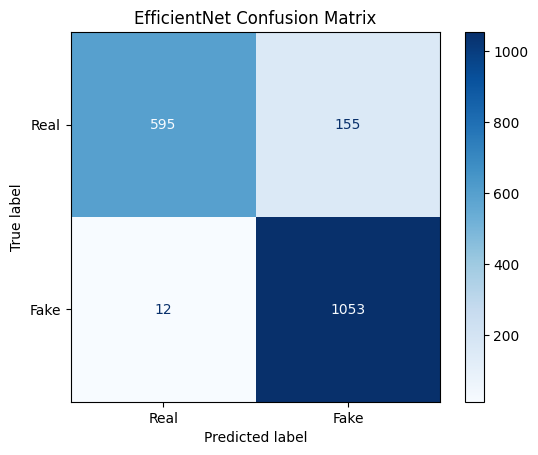

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

disp.plot(cmap="Blues")

plt.title("EfficientNet Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Real","Fake"]
))

              precision    recall  f1-score   support

        Real       0.98      0.79      0.88       750
        Fake       0.87      0.99      0.93      1065

    accuracy                           0.91      1815
   macro avg       0.93      0.89      0.90      1815
weighted avg       0.92      0.91      0.91      1815



In [ ]:
import pandas as pd

efficientnet_results = pd.DataFrame({
    "Model":["EfficientNet-B0"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1 Score":[f1],
    "AUC":[auc]
})

efficientnet_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,EfficientNet-B0,0.907989,0.871689,0.988732,0.926529,0.922287


In [ ]:
efficientnet_results.to_csv(
    "/content/drive/MyDrive/research_data/efficientnet_results.csv",
    index=False
)

print("Results Saved Successfully!")

Results Saved Successfully!


**Second Model: ConvNeXt-Tiny Model**

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

In [ ]:
# Load pretrained ConvNeXt-Tiny
convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# Replace classifier for binary classification
convnext.classifier[2] = nn.Linear(
    convnext.classifier[2].in_features,
    2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
convnext = convnext.to(device)

print(convnext)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 191MB/s] 


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    convnext.parameters(),
    lr=1e-4
)

In [ ]:
print("="*50)
print("Model Loaded Successfully")
print("="*50)

print("Device :", device)
print("Model  :", "ConvNeXt-Tiny")

Model Loaded Successfully
Device : cuda
Model  : ConvNeXt-Tiny


In [ ]:
num_epochs = 5

best_val_acc = 0.0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

num_epochs = 5

best_val_acc = 0.0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(num_epochs):

    # ===========================
    # Training
    # ===========================
    convnext.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = convnext(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===========================
    # Validation
    # ===========================
    convnext.eval()

    val_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = convnext(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)

    val_acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("="*60)
    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            convnext.state_dict(),
            "/content/drive/MyDrive/research_data/best_convnext.pth"
        )

        print("✅ Best Model Saved")

print("="*60)
print("Training Completed!")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")

Epoch 1/5
Train Loss : 0.4283
Train Acc  : 0.8018
Val Loss   : 0.3094
Val Acc    : 0.8777
Precision  : 0.8814
Recall     : 0.9146
F1 Score   : 0.8977
✅ Best Model Saved
Epoch 2/5
Train Loss : 0.2700
Train Acc  : 0.9048
Val Loss   : 0.2447
Val Acc    : 0.9174
Precision  : 0.8790
Recall     : 0.9962
F1 Score   : 0.9340
✅ Best Model Saved
Epoch 3/5
Train Loss : 0.2449
Train Acc  : 0.9102
Val Loss   : 0.2318
Val Acc    : 0.9168
Precision  : 0.8771
Recall     : 0.9981
F1 Score   : 0.9337
Epoch 4/5
Train Loss : 0.2279
Train Acc  : 0.9140
Val Loss   : 0.2448
Val Acc    : 0.9080
Precision  : 0.8891
Recall     : 0.9634
F1 Score   : 0.9247
Epoch 5/5
Train Loss : 0.2178
Train Acc  : 0.9185
Val Loss   : 0.2205
Val Acc    : 0.9174
Precision  : 0.8797
Recall     : 0.9953
F1 Score   : 0.9339
Training Completed!
Best Validation Accuracy : 0.9174


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

convnext.load_state_dict(
    torch.load("/content/drive/MyDrive/research_data/best_convnext.pth")
)

convnext.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = convnext(images)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())


accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("="*50)
print("ConvNeXt Test Results")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc:.4f}")

ConvNeXt Test Results
Accuracy  : 0.9207
Precision : 0.8841
Recall    : 0.9953
F1 Score  : 0.9364
AUC Score : 0.9294


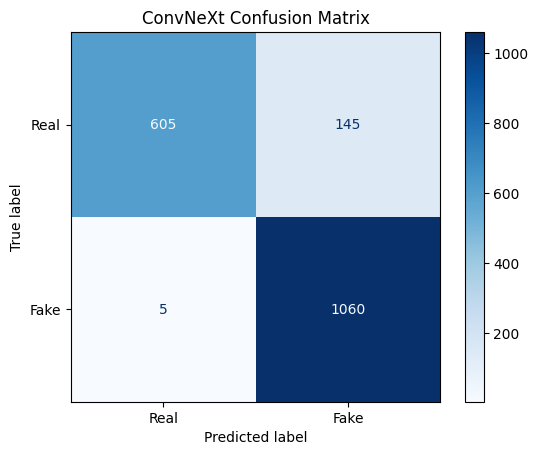

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

disp.plot(cmap="Blues")

plt.title("ConvNeXt Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Real","Fake"]
))

              precision    recall  f1-score   support

        Real       0.99      0.81      0.89       750
        Fake       0.88      1.00      0.94      1065

    accuracy                           0.92      1815
   macro avg       0.94      0.90      0.92      1815
weighted avg       0.93      0.92      0.92      1815



In [ ]:
convnext_results = pd.DataFrame({
    "Model":["ConvNeXt-Tiny"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1 Score":[f1],
    "AUC":[auc]
})

display(convnext_results)

convnext_results.to_csv(
    "/content/drive/MyDrive/research_data/convnext_results.csv",
    index=False
)

print("Results Saved Successfully!")

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,ConvNeXt-Tiny,0.920661,0.88407,0.995305,0.936396,0.929426


Results Saved Successfully!


**Model 3: Vision Transformer (ViT-Base)**

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

vit = models.vit_b_16(
    weights=models.ViT_B_16_Weights.DEFAULT
)

vit.heads.head = nn.Linear(
    vit.heads.head.in_features,
    2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vit = vit.to(device)

print(vit)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    vit.parameters(),
    lr=1e-4
)

In [ ]:
print("="*50)
print("Model Loaded Successfully")
print("="*50)

print("Device :", device)
print("Model  : Vision Transformer (ViT-B/16)")

Model Loaded Successfully
Device : cuda
Model  : Vision Transformer (ViT-B/16)


In [ ]:
num_epochs = 5

best_val_acc = 0.0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

num_epochs = 5

best_val_acc = 0.0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(num_epochs):

    # ==========================
    # Training
    # ==========================
    vit.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = vit(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ==========================
    # Validation
    # ==========================
    vit.eval()

    val_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = vit(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)

    val_acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("="*60)
    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            vit.state_dict(),
            "/content/drive/MyDrive/research_data/best_vit.pth"
        )

        print("✅ Best Model Saved")

print("="*60)
print("Training Completed!")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")

KeyboardInterrupt: 

In [ ]:
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

265
57
57


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
print(len(train_loader))

265


In [ ]:
import time

start = time.time()

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

print("Time:", time.time() - start)

torch.Size([32, 3, 224, 224])
torch.Size([32])
Time: 2.250278949737549


In [ ]:
images = images.to(device)
labels = labels.to(device)

print("Moved to GPU")

Moved to GPU


In [ ]:
vit.eval()

with torch.no_grad():
    out = vit(images)

print(out.shape)

torch.Size([32, 2])


In [ ]:
vit.train()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = vit(images)

loss = criterion(outputs, labels)

print("Forward Done")

loss.backward()

print("Backward Done")

optimizer.step()

print("Optimizer Done")

Forward Done
Backward Done
Optimizer Done


In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

num_epochs = 5
best_val_acc = 0.0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):

    print("="*60)
    print(f"Epoch {epoch+1}/{num_epochs}")

    # ======================
    # Training
    # ======================
    vit.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = vit(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ======================
    # Validation
    # ======================
    vit.eval()

    val_running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = vit(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)

    val_acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            vit.state_dict(),
            "/content/drive/MyDrive/research_data/best_vit.pth"
        )

        print("✅ Best Model Saved")

print("="*60)
print("Training Completed!")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")

Epoch 1/5
Train Loss : 0.6785
Train Acc  : 0.5812
Val Loss   : 0.6677
Val Acc    : 0.5868
Precision  : 0.5868
Recall     : 1.0000
F1 Score   : 0.7396
✅ Best Model Saved
Epoch 2/5
Train Loss : 0.6686
Train Acc  : 0.5982
Val Loss   : 0.6599
Val Acc    : 0.5956
Precision  : 0.5920
Recall     : 1.0000
F1 Score   : 0.7437
✅ Best Model Saved
Epoch 3/5
Train Loss : 0.6615
Train Acc  : 0.6014
Val Loss   : 0.6380
Val Acc    : 0.6380
Precision  : 0.6201
Recall     : 0.9887
F1 Score   : 0.7622
✅ Best Model Saved
Epoch 4/5
Train Loss : 0.6260
Train Acc  : 0.6439
Val Loss   : 0.6331
Val Acc    : 0.6446
Precision  : 0.6558
Recall     : 0.8300
F1 Score   : 0.7327
✅ Best Model Saved
Epoch 5/5
Train Loss : 0.5867
Train Acc  : 0.6889
Val Loss   : 0.5368
Val Acc    : 0.7377
Precision  : 0.7358
Recall     : 0.8629
F1 Score   : 0.7943
✅ Best Model Saved
Training Completed!
Best Validation Accuracy : 0.7377
